<div style="margin-bottom: 32px;">
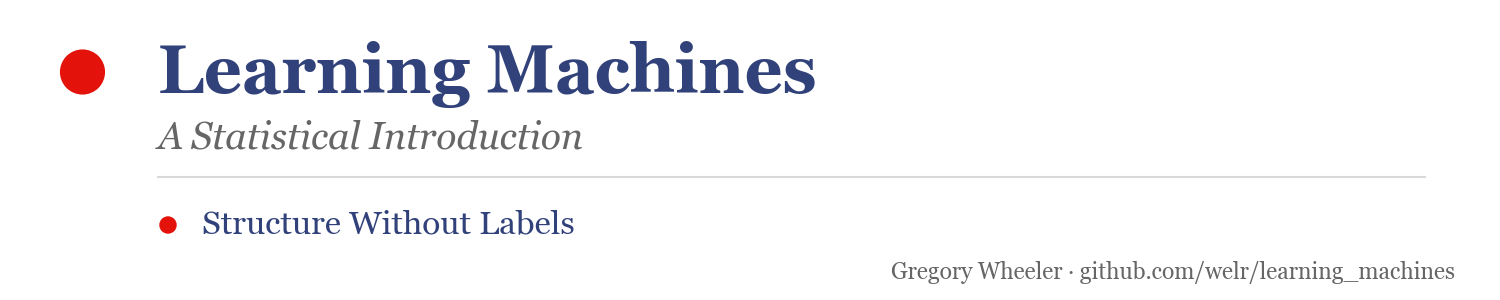
</div>


# Structure Without Labels — Unsupervised Fashion-MNIST

This notebook takes the Fashion-MNIST images from the Chapter 9 applied notebook and **withholds the labels**. We look for structure with PCA and $K$-means, using nothing but the pixels; only then do we break the seal and see how much of the class structure was already sitting in $p(\mathbf{x})$. A small autoencoder closes the loop. Companion to Chapter 13.

In [1]:
import warnings
warnings.filterwarnings("ignore")          # quiet a benign OpenML fetch warning
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                      # green companion-notebook palette
np.random.seed(0); torch.manual_seed(0)

## The data, with the labels sealed

Fashion-MNIST is 70,000 grayscale images of garments, 28×28 pixels, ten classes. We keep 10,000 of them, flatten each to a 784-vector, scale pixels to $[0,1]$ — and lock the labels away in a variable we promise not to look at until Section 4. Everything before that point uses the pixels alone.

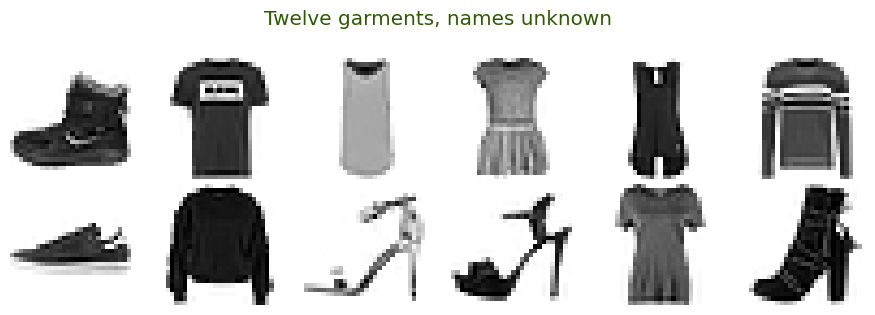

X: (10000, 784)


In [2]:
X_all, y_all = fetch_openml("Fashion-MNIST", version=1, as_frame=False,
                            return_X_y=True, parser="auto")
m = 10_000
X = X_all[:m].astype(np.float64) / 255.0
y_sealed = y_all[:m].astype(int)            # sealed until Section 4
del X_all, y_all

fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for ax, i in zip(axes.ravel(), range(12)):
    ax.imshow(X[i].reshape(28, 28), cmap="gray_r")
    ax.axis("off")                          # no titles: we have no labels
fig.suptitle("Twelve garments, names unknown", color=mt.FOREST)
plt.tight_layout(); plt.show()
print("X:", X.shape)

## 1. Principal components, by hand

PCA needs three lines: center the data, form the sample covariance $\mathbf{S} = \frac{1}{m}\mathbf{X}_c^T\mathbf{X}_c$, and take its eigenvectors. The 784×784 eigendecomposition runs in a second or two (`sklearn.decomposition.PCA` does the same job via an SVD).

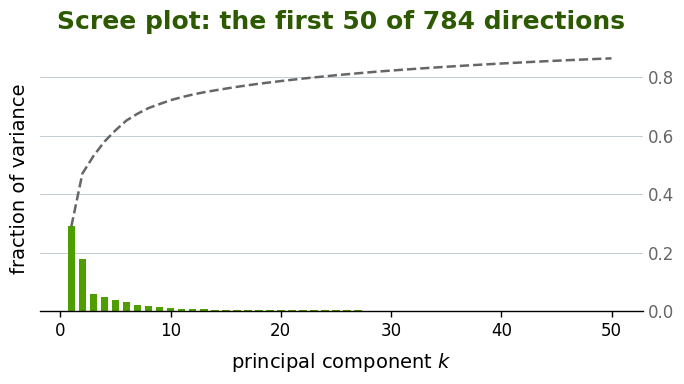

top   2 components carry 47.1% of the variance
top  20 components carry 78.6% of the variance
top  50 components carry 86.4% of the variance
top 100 components carry 91.4% of the variance


In [3]:
x_mean = X.mean(axis=0)
Xc = X - x_mean
S = Xc.T @ Xc / m                           # 784 x 784 sample covariance

evals, evecs = np.linalg.eigh(S)            # ascending order
evals, evecs = evals[::-1], evecs[:, ::-1]  # largest first

frac = evals / evals.sum()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 51), frac[:50], color=mt.GREEN, width=0.7)
ax.plot(range(1, 51), np.cumsum(frac)[:50], color=mt.GRAY, ls="--", lw=1.8)
ax.set_xlabel("principal component $k$"); ax.set_ylabel("fraction of variance")
ax.set_title("Scree plot: the first 50 of 784 directions", color=mt.FOREST)
plt.tight_layout(); plt.show()

for k in (2, 20, 50, 100):
    print(f"top {k:>3} components carry {np.cumsum(frac)[k-1]:5.1%} of the variance")

A few dozen directions carry most of the variance of 784 pixels — the images live near a much lower-dimensional sheet. And because each eigenvector is itself a 784-vector, we can look at the directions the data chose.

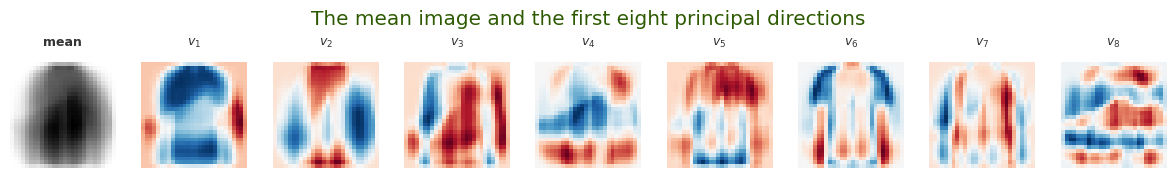

In [4]:
fig, axes = plt.subplots(1, 9, figsize=(12, 1.8))
axes[0].imshow(x_mean.reshape(28, 28), cmap="gray_r")
axes[0].set_title("mean", fontsize=9); axes[0].axis("off")
for j, ax in enumerate(axes[1:]):
    ax.imshow(evecs[:, j].reshape(28, 28), cmap="RdBu_r")
    ax.set_title(f"$v_{{{j+1}}}$", fontsize=9); ax.axis("off")
fig.suptitle("The mean image and the first eight principal directions", color=mt.FOREST)
plt.tight_layout(); plt.show()

The components are recognizably about garments: broad light/dark contrasts first (trouser-shaped vs. shirt-shaped mass), then sleeves, shoulders, and shoe outlines. Nobody told the algorithm what a sleeve is; it is simply where the pixels co-vary.

Reconstruction shows what keeping $k$ components costs. With the top $k$ eigenvectors $\mathbf{V}_k$, the reconstruction of an image is $\hat{\mathbf{x}} = \bar{\mathbf{x}} + \mathbf{V}_k\mathbf{V}_k^T(\mathbf{x}-\bar{\mathbf{x}})$.

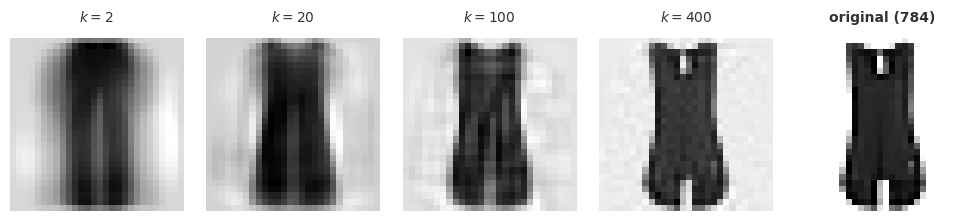

In [5]:
i = 4                                        # one garment
fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, k in zip(axes, (2, 20, 100, 400)):
    Vk = evecs[:, :k]
    x_hat = x_mean + Vk @ (Vk.T @ Xc[i])
    ax.imshow(x_hat.reshape(28, 28), cmap="gray_r")
    ax.set_title(f"$k={k}$", fontsize=10); ax.axis("off")
axes[4].imshow(X[i].reshape(28, 28), cmap="gray_r")
axes[4].set_title("original (784)", fontsize=10); axes[4].axis("off")
plt.tight_layout(); plt.show()

## 2. Two coordinates for every garment

Project all 10,000 images onto the first two components. We still have no labels, so every point gets the same color — and yet the cloud is visibly not one blob. The structure is in $p(\mathbf{x})$, waiting.

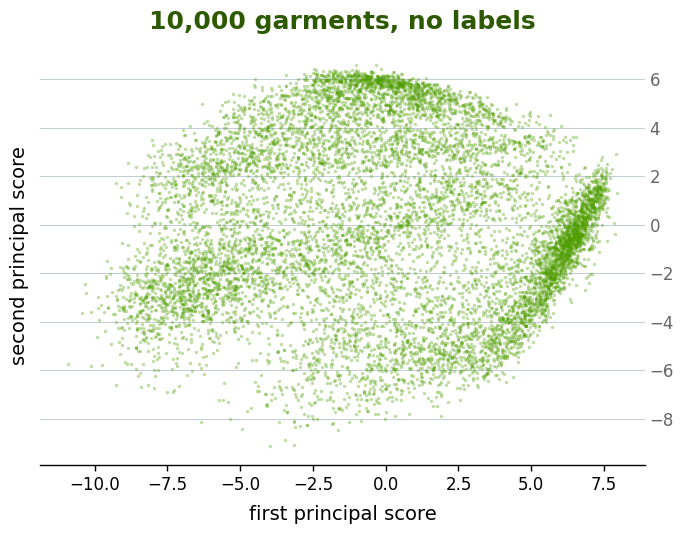

In [6]:
Z2 = Xc @ evecs[:, :2]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(Z2[:, 0], Z2[:, 1], s=6, color=mt.GREEN, alpha=0.35, linewidths=0)
ax.set_xlabel("first principal score"); ax.set_ylabel("second principal score")
ax.set_title("10,000 garments, no labels", color=mt.FOREST)
plt.tight_layout(); plt.show()

## 3. $K$-means, first by hand

Lloyd's algorithm is two alternating steps — assign each point to its nearest center, move each center to the mean of its points — and each step can only lower the objective $J$. Ten lines suffice, and watching $J$ fall reproduces the monotone descent of the chapter's worked example.

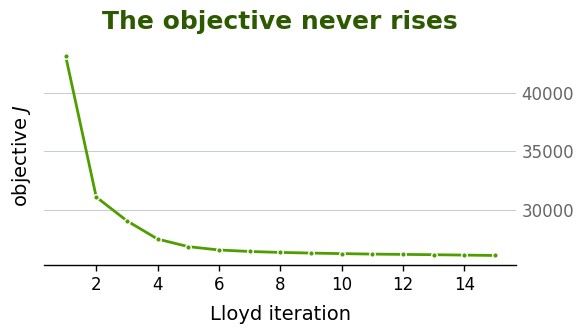

In [7]:
def lloyd(Z, K, n_iter=15, seed=0):
    rng = np.random.default_rng(seed)
    mus = Z[rng.choice(len(Z), K, replace=False)]   # init: K random points
    J_trace = []
    for _ in range(n_iter):
        d2 = ((Z[:, None, :] - mus[None, :, :]) ** 2).sum(axis=2)
        c = d2.argmin(axis=1)                        # assign
        J_trace.append(d2[np.arange(len(Z)), c].sum())
        mus = np.vstack([Z[c == k].mean(axis=0) for k in range(K)])  # update
    return c, mus, J_trace

c2, mus2, J_trace = lloyd(Z2, K=10)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(J_trace) + 1), J_trace, color=mt.GREEN, marker="o", ms=4)
ax.set_xlabel("Lloyd iteration"); ax.set_ylabel("objective $J$")
ax.set_title("The objective never rises", color=mt.FOREST)
plt.tight_layout(); plt.show()

Convergence is guaranteed; convergence to the *best* partition is not — the answer depends on the initialization. `sklearn`'s `KMeans` handles that with a spread-out initialization ($k$-means++) and several restarts, so we use it for the real run: $K=10$ clusters on the top 50 principal scores. Then the question a clustering must answer: what did it find? Averaging each cluster's images gives a face to every cluster — still without a single label.

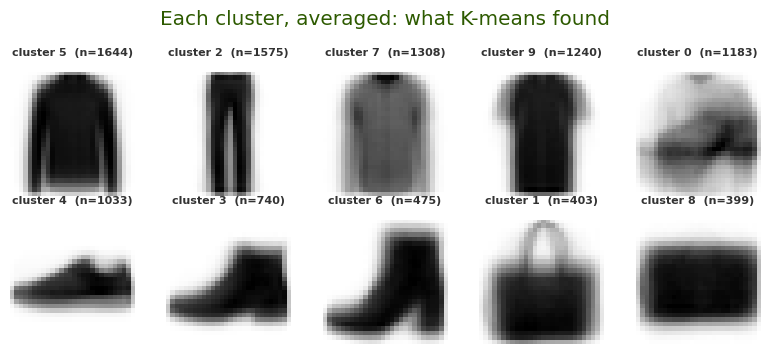

In [8]:
Z50 = Xc @ evecs[:, :50]
km = KMeans(n_clusters=10, n_init=10, random_state=0).fit(Z50)
cluster = km.labels_

fig, axes = plt.subplots(2, 5, figsize=(8, 3.6))
order = np.argsort(-np.bincount(cluster))            # biggest clusters first
for ax, k in zip(axes.ravel(), order):
    ax.imshow(X[cluster == k].mean(axis=0).reshape(28, 28), cmap="gray_r")
    ax.set_title(f"cluster {k}  (n={np.sum(cluster == k)})", fontsize=8)
    ax.axis("off")
fig.suptitle("Each cluster, averaged: what K-means found", color=mt.FOREST)
plt.tight_layout(); plt.show()

Trousers, bags, ankle boots, and several upper-body garments are clearly visible as cluster averages. The algorithm has, in effect, proposed a catalogue taxonomy from pixels alone.

## 4. Breaking the seal

Now, and only now, we look at `y_sealed`.

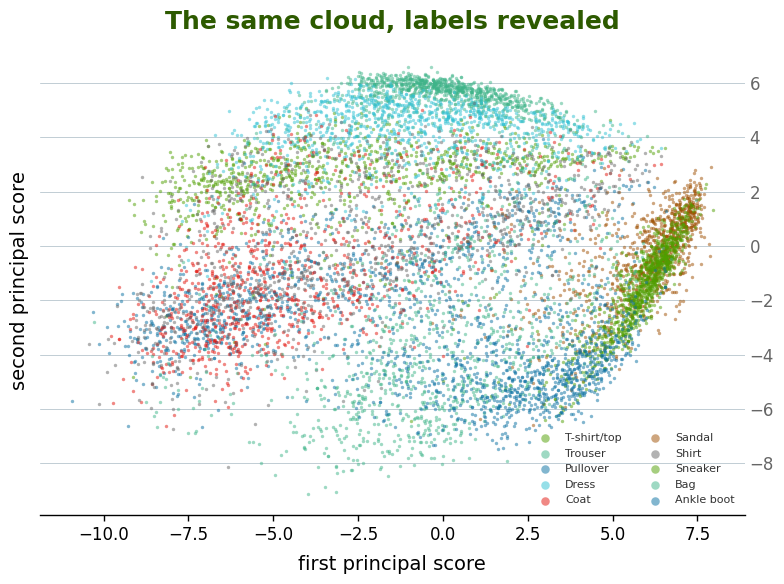

In [9]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, ax = plt.subplots(figsize=(8, 6))
for cls in range(10):
    pts = Z2[y_sealed == cls]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5, linewidths=0, label=classes[cls])
ax.set_xlabel("first principal score"); ax.set_ylabel("second principal score")
ax.set_title("The same cloud, labels revealed", color=mt.FOREST)
ax.legend(markerscale=2.5, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [10]:
# Cross-tabulate clusters against the (now unsealed) classes
tab = np.zeros((10, 10), dtype=int)
for k, cls in zip(cluster, y_sealed):
    tab[k, cls] += 1

header = " cluster | " + " ".join(f"{c[:6]:>6}" for c in classes)
print(header); print("-" * len(header))
for k in range(10):
    print(f"      {k}  | " + " ".join(f"{tab[k, cls]:>6}" for cls in range(10)))

purity = tab.max(axis=1).sum() / len(cluster)
print(f"\ncluster purity: {purity:.1%}  "
      "(fraction of images in their cluster's majority class)")

 cluster | T-shir Trouse Pullov  Dress   Coat Sandal  Shirt Sneake    Bag Ankle 
--------------------------------------------------------------------------------
      0  |     61     20     64     65     28    652     96    103     66     28
      1  |      1      0      6      0      7      3      3      0    383      0
      2  |     39    925      0    579     18      0     11      0      3      0
      3  |      0      0      0      0      0     74      0    142      8    516
      4  |      0      0      0      0      0    207      1    771     31     23
      5  |     12     19    610      6    607      0    343      0     47      0
      6  |      0      0      0      0      0     40      0      6      0    429
      7  |    284     18    301    115    162     13    339      0     72      4
      8  |      4      0      5      0      1      0     12      0    377      0
      9  |    541     45     30    254    151      0    216      0      3      0

cluster purity: 55.4%  (fra

The cross-tabulation says, quantitatively, what the pictures suggested — and adds surprises. Bags and sneakers form nearly single-class clusters; ankle boots split across two clusters, one 90% boots and one 70% (two boot silhouettes, the second shared with sneakers and sandals). Trousers merge with dresses: to a pixel-space distance, what matters is the elongated silhouette, not the garment's name. And the upper-body triad — pullover, coat, shirt — collapses into shared clusters, the same classes the *supervised* network confused in the Chapter 9 notebook. The difficulty lives in $p(\mathbf{x})$ itself, not in the method. Overall purity is 55%: a bit more than half of the class structure was recoverable before a single label was used, and the errors are not random but systematic, along directions of genuine visual similarity.

## 5. An autoencoder's two coordinates

PCA's two coordinates are the best *linear* summary. A small autoencoder — encoder 784 → 128 → 2, decoder mirroring it back — learns a nonlinear one, trained only to reconstruct its input. A linear autoencoder would recover PCA exactly (Chapter 13, Exercise 9); the nonlinearity is what lets the code bend.

In [11]:
class AutoEncoder(nn.Module):
    def __init__(self, code_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 128), nn.ReLU(),
                                 nn.Linear(128, code_dim))
        self.dec = nn.Sequential(nn.Linear(code_dim, 128), nn.ReLU(),
                                 nn.Linear(128, 784), nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

ae = AutoEncoder()
opt = torch.optim.AdamW(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
Xt = torch.tensor(X, dtype=torch.float32)

for epoch in range(8):
    perm = torch.randperm(m)
    for i in range(0, m, 256):
        batch = Xt[perm[i:i + 256]]
        opt.zero_grad()
        loss = loss_fn(ae(batch), batch)     # the target is the input itself
        loss.backward(); opt.step()
    print(f"epoch {epoch + 1}: reconstruction MSE {loss.item():.4f}")

epoch 1: reconstruction MSE 0.0718
epoch 2: reconstruction MSE 0.0687
epoch 3: reconstruction MSE 0.0391
epoch 4: reconstruction MSE 0.0379


epoch 5: reconstruction MSE 0.0286
epoch 6: reconstruction MSE 0.0359
epoch 7: reconstruction MSE 0.0439
epoch 8: reconstruction MSE 0.0294


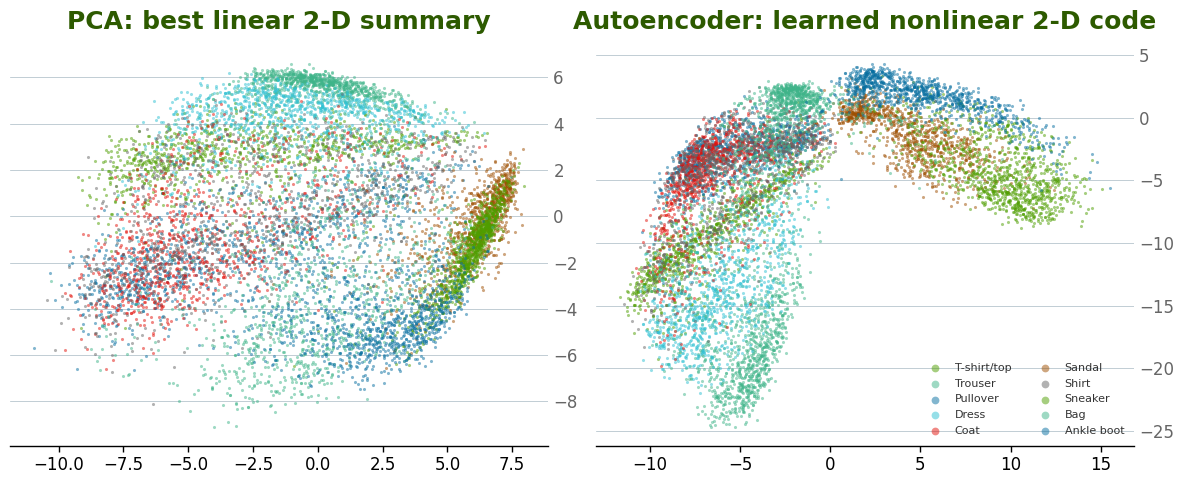

In [12]:
with torch.no_grad():
    codes = ae.enc(Xt).numpy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
for cls in range(10):
    a1.scatter(*Z2[y_sealed == cls].T, s=5, alpha=0.5, linewidths=0)
    a2.scatter(*codes[y_sealed == cls].T, s=5, alpha=0.5, linewidths=0,
               label=classes[cls])
a1.set_title("PCA: best linear 2-D summary", color=mt.FOREST)
a2.set_title("Autoencoder: learned nonlinear 2-D code", color=mt.FOREST)
a2.legend(markerscale=2.5, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

Both plots are colored by the revealed labels, but neither method ever saw them. The autoencoder's code typically pulls the footwear classes further from the garments and gives the trousers their own peninsula — a curved sheet where PCA could only offer a flat one. Which summary is "better" depends on what you ask of it; what they share is the chapter's point: the objective never mentioned classes, and the classes emerged anyway.

## Try next

- **Vary $K$.** Run $K$-means with $K = 5$ and $K = 20$. Do the extra clusters split classes or split noise? The mixture-model reading of Chapter 13 says held-out likelihood could adjudicate — purity against sealed labels is a luxury real problems don't have.
- **Cluster in pixel space.** Rerun $K$-means on the raw 784 pixels instead of 50 principal scores. Does the result change much? What does that say about what the discarded components contained?
- **Widen the bottleneck.** Change the code dimension from 2 to 16 and compare reconstruction MSE. Then remove the bottleneck entirely (code dimension 784) and explain what the network learns.
- **Denoise.** Corrupt each training batch with Gaussian noise and reconstruct the *clean* image. The learned code often improves — the denoising idea that Chapter 13 connects to masked pretraining.